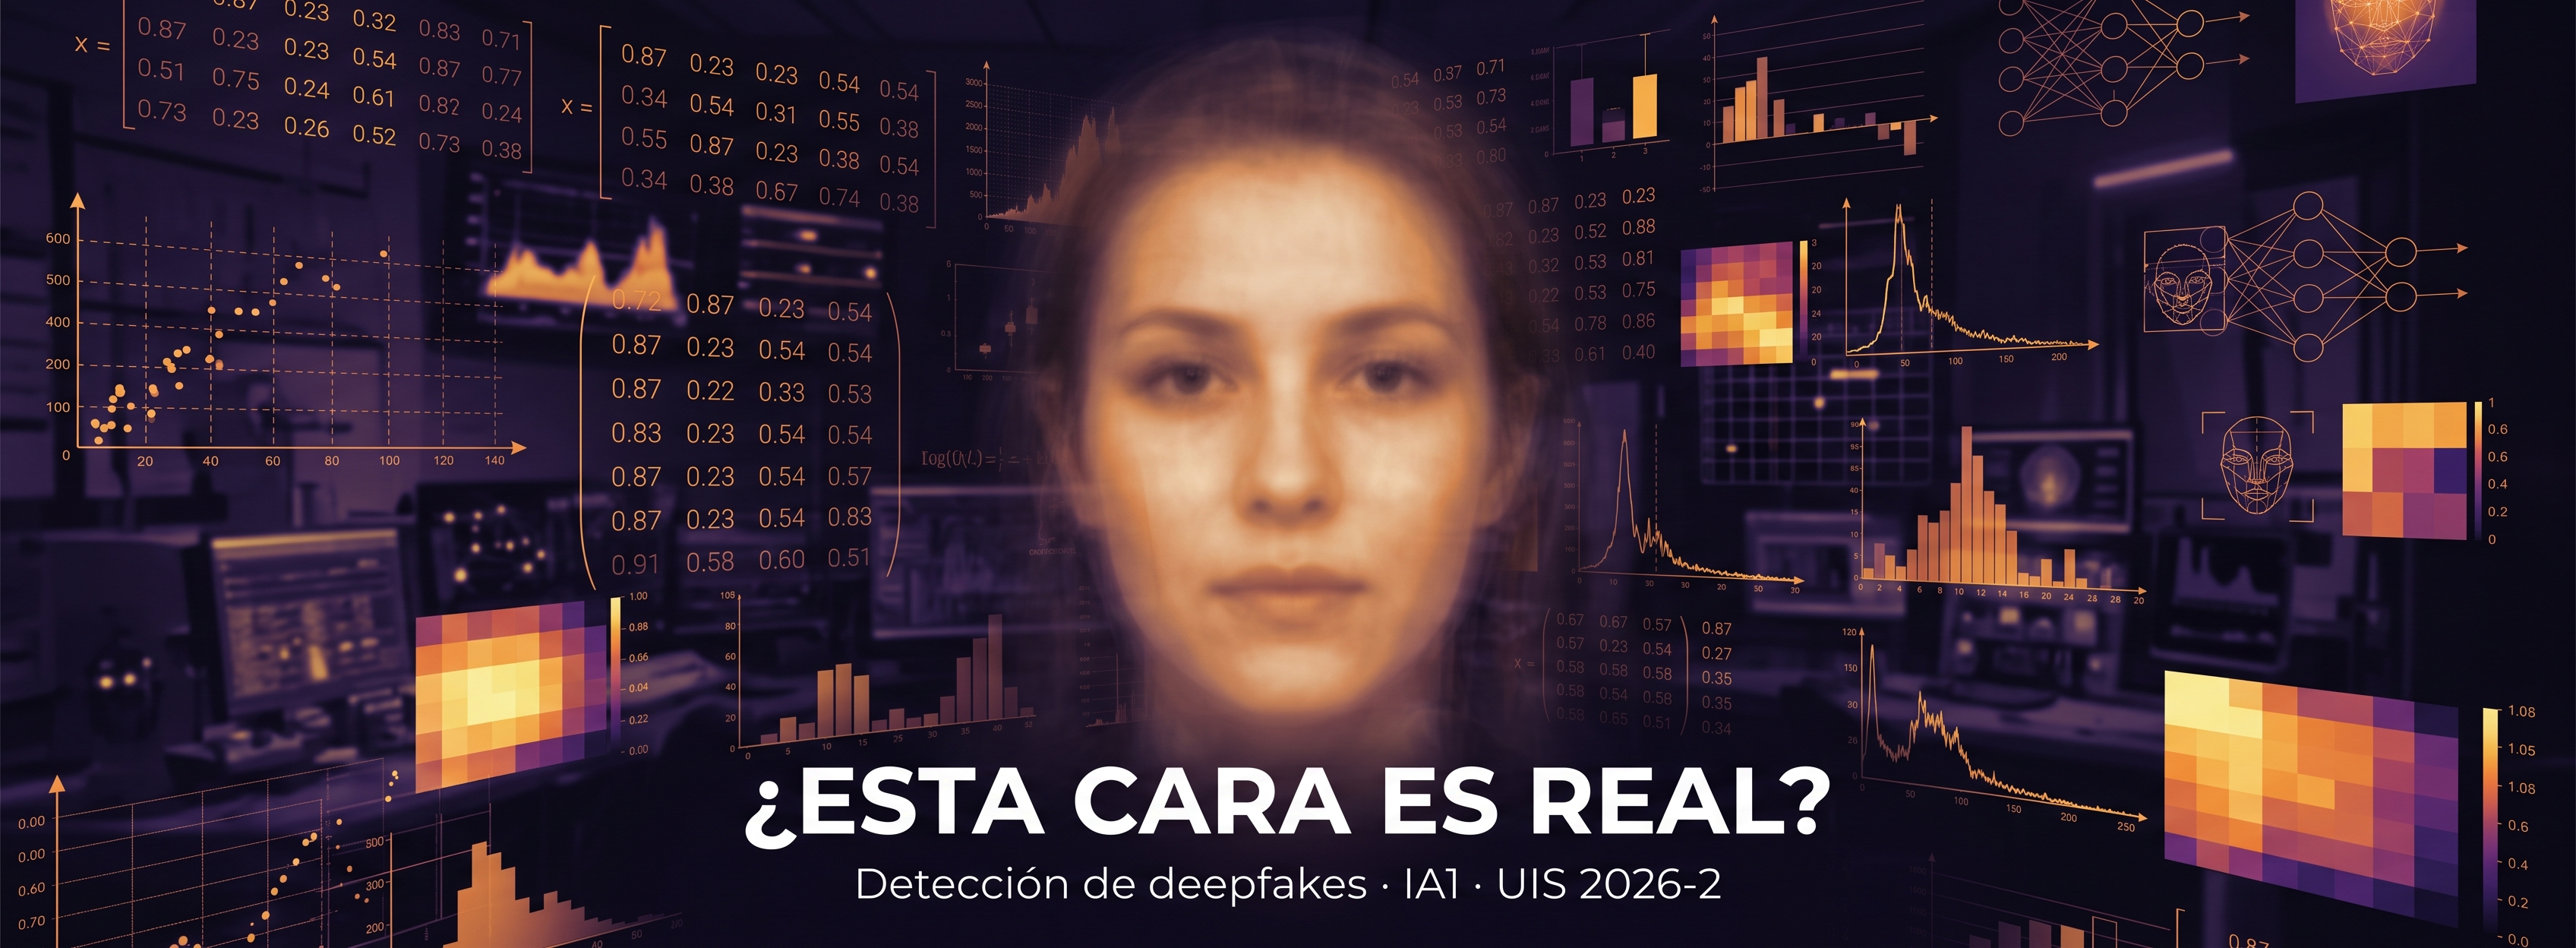

In [4]:
import os, glob
from IPython.display import Image, display

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive; drive.mount('/content/drive')

display(Image(glob.glob('/content/drive/MyDrive/IA1_deepfake/BannerProyectoIA*')[0]))

# ¿Esta cara es real?

### Detección de rostros generados o manipulados por IA (deepfake) en imágenes mediante algoritmos clásicos de aprendizaje automático

**Proyecto final · Inteligencia Artificial 1 · Universidad Industrial de Santander · 2026-2**
**Integrantes:** Juan Daniel Torres Ramírez (2240082) · Sebastian Castellanos Prada (2240037)

---

## El problema

Existen herramientas comerciales que cambian la cara de una persona en una fotografía, y el
resultado es tan bueno que **una persona no nota el cambio a simple vista**. Eso se usa para
suplantar identidades, para estafas y para desinformación.

La pregunta del proyecto es: **dada la foto de un rostro, ¿es auténtica o la manipuló
una IA?**

La diferencia con los proyectos habituales de rostros está justo en esa pregunta. Los demás
preguntan *"¿quién es esta cara?"*; nosotros preguntamos *"¿esta cara es de verdad?"*.

**¿Clasificación o regresión?** → **Clasificación binaria.** La respuesta es una de dos
etiquetas: real o falsa.

## Cómo vamos a abordar el proyecto

| Etapa | Qué se hace |
|---|---|
| **Avance 1 — este notebook** | Conocer los datos: cuántas imágenes hay, de qué tipo, estandarizar su tamaño, calcular la imagen promedio y la de desviación, y detectar qué trampas esconde el dataset |
| **Avance 2** | Posteriores Entregas |
| **Avance 3** | Posteriores Entregas |

## El dataset

**HiDF — *A Human-Indistinguishable Deepfake Dataset***
Kang et al., KDD 2025 · DOI 10.1145/3711896.3737399 · https://zenodo.org/records/16140829 · CC-BY-NC-4.0

Son fotos de rostros publicadas en 2025 como referencia para investigación. Lo que lo hace
interesante es que **las falsas fueron curadas a mano para que un humano no las distinga**:
es un dataset difícil a propósito.

| | |
|---|---|
| Imágenes reales | **38.582** archivos → **38.540** personas distintas |
| Imágenes falsas | **31.249** archivos |
| De dónde salen las reales | CelebA-HQ (IDs que empiezan por `c`) y FFHQ (IDs por `f`) |
| Cómo se hicieron las falsas | *face swap*: se pega la cara de una persona sobre la foto de otra |
| Tamaño de cada imagen | **1024 × 1024**, ya recortadas y centradas en el rostro |
| Extra | `metadata.csv` con raza, género y edad de cada rostro real |

**El nombre del archivo dice cómo se hizo.** `c00002_c00003.jpg` significa: se tomó la foto
`c00002` y se le puso encima la identidad de `c00003`.

**Vamos a usar el dataset completo.** Los ZIP pesan 12,6 GB (falsas) y 27,8 GB (reales). Se
descargan una sola vez al disco temporal de Colab, se reduce cada imagen a 64 × 64 y solo el
resultado —unos 857 MB— se guarda en Google Drive. De ahí en adelante todo el proyecto trabaja
sobre ese archivo pequeño. El procedimiento está en la sección 3.

### De dónde vienen las caras reales

Las imágenes reales no las tomaron los autores de HiDF: las sacaron de dos colecciones que ya
son un estándar en investigación de rostros.

**CelebA-HQ** (IDs que empiezan por `c`). Son 30.000 fotos de famosos, sacadas de CelebA. Una
base de fotos de prensa y alfombra roja. El equipo de NVIDIA las limpió y las escaló a
1024 × 1024 en 2018 para poder entrenar generadores de caras. Al venir de fotos de prensa,
tienden a ser gente conocida, muy maquillada y bien iluminada.

**FFHQ**: *Flickr-Faces-HQ* (IDs que empiezan por `f`). Son 70.000 fotos que NVIDIA recogió de
Flickr en 2019, también a 1024 × 1024. Se armó justo para arreglar los defectos de CelebA-HQ:
son personas cualquiera, con mucha más variedad de edad, origen, gafas, sombreros, fondos e
iluminación.

**Qué tienen en común y por qué importa:** en las dos, cada cara está **alineada**, se detectan
los ojos y se rota y recorta la foto para que queden siempre en la misma posición. Gracias a eso
todas nuestras imágenes son comparables píxel a píxel, y por eso la imagen promedio de la
sección 6 se va a ver como una cara y no como una mancha.

**Por qué el dataset usa las dos:** mezclarlas da variedad de personas y de condiciones de foto.
Si solo se usara una, un detector podría aprender el estilo de esa colección en vez de aprender
a detectar manipulaciones.

---

# Avance 1 — Exploración de datos

De aquí en adelante empieza el trabajo de este avance. El recorrido es:

| Sección | Qué responde |
|---|---|
| 1. Entorno | dónde trabajamos y con qué recursos |
| 2. Los datos tabulares | qué nos dice el `metadata.csv` sobre quién aparece en el dataset |
| 3. Descargar y reducir las imágenes | cómo manejamos 40 GB en Colab gratis |
| 4. Estandarizar el tamaño | por qué 64 × 64 y qué se pierde al reducir |
| 5. Tabla numérica de las imágenes | qué se puede medir de cada foto |
| 6. La imagen promedio | cómo se ve el rostro "medio" de cada clase |
| 7. La imagen de desviación | dónde cambian las imágenes entre sí |
| 8. Escala de grises | lo que recomendó el profesor, sobre todo el conjunto |
| 9. Para qué sirven el promedio y la desviación | su uso real: normalizar |
| 10. Dos trampas en los datos | cómo se podría obtener un resultado excelente y falso |
| 11. Guardar el resultado | qué queda listo para el Avance 2 |
| 12. Conclusiones | qué aprendimos y qué sigue |


## 1. Entorno

In [5]:
import io, os, time, glob, shutil, zipfile
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image

# Montamos Google Drive: ahi guardamos los ZIP y las imagenes ya procesadas.
from google.colab import drive
drive.mount('/content/drive')

BASE = "https://zenodo.org/records/16140829/files"
ZIPS = {"fake": "Fake-img.zip", "real": "Real-img.zip"}

S       = 64      # lado final de cada imagen (64 x 64 pixeles)
PASO    = 2000    # cada cuantas imagenes guardamos un archivo parcial
CARPETA = "/content/drive/MyDrive/IA1_deepfake"

os.makedirs(f"{CARPETA}/parciales", exist_ok=True)
print("carpeta de trabajo:", CARPETA, "\n")

!free -h | head -2          # memoria RAM disponible (necesitamos ~1 GB)
!df -h /content | tail -1   # espacio en el disco local (necesitamos ~28 GB libres)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
carpeta de trabajo: /content/drive/MyDrive/IA1_deepfake 

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.3Gi       9.1Gi       2.8Mi       2.5Gi        11Gi
overlay         108G   21G   88G  19% /


## 2. Los datos tabulares: `metadata.csv`

El dataset trae un CSV que describe **cada rostro real**: quién es y en qué papel aparece.

In [6]:
!wget -q -O metadata.csv "https://zenodo.org/records/16140829/files/metadata.csv?download=1"

meta = pd.read_csv("metadata.csv")

# El CSV viene sucio: algunos valores traen espacios al final ("White  ", "Female ").
# Sin esto, pandas cuenta "White" y "White  " como dos categorias distintas.
for c in ["Img/Vid", "Base/Swap", "Race", "Gender", "Age"]:
    meta[c] = meta[c].astype(str).str.strip()

# El CSV mezcla imagenes y videos. Nuestro proyecto es solo de imagenes.
meta = meta[meta["Img/Vid"] == "Img"].drop(columns="Img/Vid").reset_index(drop=True)

print("filas de imagen:", len(meta))
meta.head()

filas de imagen: 38540


,ID,Base/Swap,Race,Gender,Age
0,c29807,"Base, Swap",White,Female,Adult
1,c00002,"Base, Swap",White,Female,Adult
2,c00003,"Base, Swap",Latino,Female,Adult
3,c00004,"Base, Swap",White,Male,Adult
4,c00007,"Base, Swap",Black,Female,Adult


**¿Qué significa cada columna?**

- `ID` — identificador del rostro. Empieza por `c` si viene de CelebA-HQ, por `f` si viene de FFHQ.
- `Base/Swap` — el papel que juega esa persona al construir las falsas:
  `Base` = su foto se usó como fondo · `Swap` = su cara se pegó sobre otra · `Base, Swap` = las dos.
- `Race`, `Gender`, `Age` — características del rostro, anotadas por los autores del dataset.

In [7]:
print("COLUMNAS:", meta.columns.tolist())
print()
meta.info()          # tipo de dato de cada columna y cuantos valores no nulos hay

COLUMNAS: ['ID', 'Base/Swap', 'Race', 'Gender', 'Age']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38540 entries, 0 to 38539
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         38540 non-null  object
 1   Base/Swap  38540 non-null  object
 2   Race       38540 non-null  object
 3   Gender     38540 non-null  object
 4   Age        38540 non-null  object
dtypes: object(5)
memory usage: 1.5+ MB


In [8]:
# describe() con include="all" porque todas las columnas son de texto:
# muestra cuantos valores distintos hay, cual es el mas frecuente y cuantas veces aparece.
meta.describe(include="all")

,ID,Base/Swap,Race,Gender,Age
count,38540,38540,38540,38540,38540
unique,38540,3,5,2,3
top,f42105,"Base, Swap",White,Female,Adult
freq,1,21484,29011,23327,32001


### 2.1 Gráficas de las columnas categóricas

Son todas categóricas (texto, no números), así que la gráfica que corresponde es la de torta.

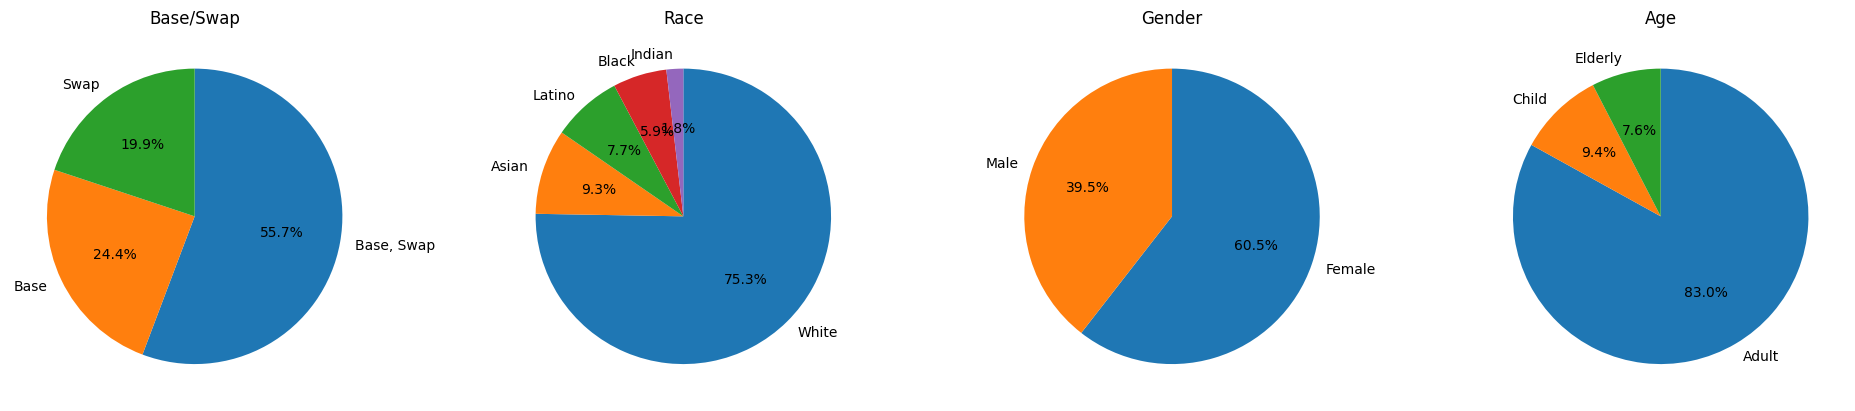

Base/Swap
Base, Swap    21484
Base           9387
Swap           7669
Name: count, dtype: int64 

Race
White     29011
Asian      3596
Latino     2952
Black      2272
Indian      709
Name: count, dtype: int64 

Gender
Female    23327
Male      15213
Name: count, dtype: int64 

Age
Adult      32001
Child       3615
Elderly     2924
Name: count, dtype: int64 



In [9]:
cols = ["Base/Swap", "Race", "Gender", "Age"]

fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))
for a, c in zip(ax, cols):
    vc = meta[c].value_counts()                      # cuenta cuantas veces aparece cada valor
    a.pie(vc, labels=vc.index, autopct="%1.1f%%", startangle=90, counterclock=False)
    a.set_title(c, fontsize=12)
plt.tight_layout(); plt.show()

for c in cols:
    print(meta[c].value_counts(), "\n")

**¿Qué observamos?** El dataset está muy **desbalanceado en demografía**: 75 % de los rostros son
blancos, frente a 7,7 % latinos y 1,8 % indios. Por otro lado, 60,5 % de los rostros son de mujeres mientras que 39,5 % de los rostros son de hombres.

Esto no daña el proyecto, porque lo que vamos a predecir es real/falsa, no la raza. Pero sí es
un dato importante: si el detector funciona bien en general puede estar funcionando mal en los
grupos poco representados, y eso lo podemos medir gracias a esta columna.

## 3. Descargar y reducir todas las imágenes

Vamos a usar **todas** las imágenes del dataset. El problema es que los ZIP suman 40 GB, así que
el procedimiento tiene dos pasos.

**Paso 1 — descargar los ZIP al disco temporal de Colab.** No a Drive: escribir 40 GB a través
del montaje de Drive iba a **634 kB/s**, con un tiempo estimado de más de 5 horas. Bajándolos al
disco local de la máquina y con **16 conexiones en paralelo** (`aria2c`), la velocidad media fue
de **30 MB/s** y los 40 GB tardaron unos 25 minutos. Zenodo limita la velocidad por conexión, y
además tarda cerca de minuto y medio en empezar a servir un archivo grande: el `0B/0B` inicial no
es un error.

**Paso 2 — reducir cada imagen a 64 × 64.** Se lee cada archivo dentro del ZIP, se decodifica, se
reduce y se guarda en un arreglo; el original se descarta. Lo único que queda en Drive son las
imágenes reducidas, 857 MB.

**Dos detalles que importan:**

- **`draft`**: en vez de armar la imagen completa de 1024 × 1024 y luego encogerla, le pedimos a
  PIL que decodifique el JPEG ya pequeño (a 128 × 128). La
  diferencia con la versión normal es de 0,6 sobre 255, imperceptible.
- **Guardado por tandas**: cada 2.000 imágenes se escribe un archivo parcial en Drive. Si Colab se
  desconecta, se vuelve a ejecutar la celda: salta lo que ya está hecho y sigue desde ahí.

**Por qué descargamos el ZIP entero.** La primera versión pedía trozos sueltos por rangos HTTP
para no bajar los 40 GB. Funciona, pero si el servidor devuelve una respuesta incompleta el
archivo llega cortado y el proceso se cae con `Error -5: incomplete or truncated stream`.
Descargando el ZIP completo, `zipfile` de Python verifica cada archivo por su cuenta y ese
problema desaparece.

In [6]:
# El cuello de botella eran dos cosas: escribir directo en Drive (lento) y usar
# una sola conexion (Zenodo limita por conexion). Ahora descargamos al disco local
# de Colab con 16 conexiones en paralelo. Los ZIP son temporales: a Drive solo va
# el resultado de 857 MB.
!apt-get -qq install -y aria2 > /dev/null

for nombre in ZIPS.values():
    print(f"--- {nombre} ---")
    !aria2c -c -x16 -s16 -k1M --summary-interval=20 --console-log-level=warn \
            -d /content -o "{nombre}" "{BASE}/{nombre}?download=1"

# Comprobamos que llegaron completos y que no estan corruptos.
for nombre in ZIPS.values():
    ruta = f"/content/{nombre}"
    print(f"{nombre}: {os.path.getsize(ruta)/1e9:.1f} GB", end="  ->  ")
    try:
        with zipfile.ZipFile(ruta) as z:
            print(f"OK, {len(z.infolist())} entradas")
    except Exception as e:
        print("DAÑADO:", e, "-> borra el archivo y vuelve a correr la celda")

--- Fake-img.zip ---
 *** Download Progress Summary as of Mon Sep 14 06:09:46 2026 *** 
=
[#c895f1 0B/0B CN:1 DL:0B]
FILE: /content/Fake-img.zip
-

 *** Download Progress Summary as of Mon Sep 14 06:10:06 2026 *** 
=
[#c895f1 0B/0B CN:1 DL:0B]
FILE: /content/Fake-img.zip
-

 *** Download Progress Summary as of Mon Sep 14 06:10:26 2026 *** 
=
[#c895f1 0B/0B CN:1 DL:0B]
FILE: /content/Fake-img.zip
-

 *** Download Progress Summary as of Mon Sep 14 06:10:46 2026 *** 
=
[#c895f1 0B/0B CN:1 DL:0B]
FILE: /content/Fake-img.zip
-

 *** Download Progress Summary as of Mon Sep 14 06:11:06 2026 *** 
=
[#c895f1 0B/0B CN:1 DL:0B]
FILE: /content/Fake-img.zip
-

 *** Download Progress Summary as of Mon Sep 14 06:11:26 2026 *** 
=
[#c895f1 272KiB/11GiB(0%) CN:16 DL:324KiB ETA:10h32m54s]
FILE: /content/Fake-img.zip
-

 *** Download Progress Summary as of Mon Sep 14 06:11:46 2026 *** 
=
[#c895f1 21MiB/11GiB(0%) CN:16 DL:1.5MiB ETA:2h12m45s]
FILE: /content/Fake-img.zip
-

 *** Download Progress Summary a

In [7]:
def procesar_clase(clase):
    """Reduce TODAS las imagenes de la clase a S x S y guarda parciales en Drive.
    Si se interrumpe, volver a ejecutar: salta las tandas que ya estan guardadas."""
    zip_local = f"/content/{ZIPS[clase]}"
    if not os.path.exists(zip_local):
        raise FileNotFoundError(f"Falta {zip_local}. Corre primero la celda de descarga.")

    # Leer el indice del ZIP es rapido: solo lee el directorio que esta al final del archivo.
    with zipfile.ZipFile(zip_local) as z:
        infos = [i for i in z.infolist() if not i.is_dir()]
    infos.sort(key=lambda i: i.header_offset)   # orden fisico: leer del disco es mas rapido

    # Hay IDs repetidos con distinta extension (.jpg y .png). Nos quedamos con uno.
    vistos, fotos = set(), []
    for i in infos:
        k = os.path.splitext(os.path.basename(i.filename))[0]
        if k not in vistos:
            vistos.add(k)
            fotos.append(i)

    # Revisamos que tandas faltan antes de ponernos a trabajar.
    n_tandas = (len(fotos) + PASO - 1) // PASO
    faltan = [k for k in range(0, len(fotos), PASO)
              if not os.path.exists(f"{CARPETA}/parciales/{clase}_{k//PASO:04d}.npz")]
    print(f"{clase}: {len(fotos)} imagenes -> {n_tandas} tandas, faltan {len(faltan)}")
    if not faltan:
        print(f"{clase}: ya estaba listo\n")
        return

    with zipfile.ZipFile(zip_local) as z:
        t0, hechas = time.time(), 0
        for k in faltan:
            Xs, ids_l, pesos = [], [], []
            for e in fotos[k:k + PASO]:
                try:
                    im = Image.open(io.BytesIO(z.read(e.filename)))
                    # draft: decodifica el JPEG ya reducido (1024 -> 128) en vez de armarlo
                    # completo. Casi el doble de rapido. En PNG no aplica y PIL lo ignora.
                    im.draft("RGB", (S, S))
                    im = im.convert("RGB").resize((S, S), Image.BILINEAR)
                except Exception:
                    continue                       # si una imagen viene dañada, la saltamos
                Xs.append(np.asarray(im, dtype=np.uint8))
                ids_l.append(os.path.splitext(os.path.basename(e.filename))[0])
                pesos.append(e.file_size)

            np.savez(f"{CARPETA}/parciales/{clase}_{k//PASO:04d}.npz",
                     X=np.stack(Xs), ids=np.array(ids_l), peso=np.array(pesos))
            hechas += len(Xs)
            print(f"  tanda {k//PASO + 1}/{n_tandas}  (+{len(Xs)} img)"
                  f"   {hechas/(time.time()-t0):5.1f} img/s")

    print(f"{clase}: terminado\n")


procesar_clase("fake")
procesar_clase("real")

fake: 31249 imagenes -> 16 tandas, faltan 13
  tanda 4/16  (+2000 img)    52.8 img/s
  tanda 5/16  (+1998 img)    53.0 img/s
  tanda 6/16  (+2000 img)    46.5 img/s
  tanda 7/16  (+2000 img)    45.9 img/s
  tanda 8/16  (+2000 img)    46.2 img/s
  tanda 9/16  (+2000 img)    47.1 img/s
  tanda 10/16  (+2000 img)    45.4 img/s
  tanda 11/16  (+1999 img)    45.9 img/s
  tanda 12/16  (+2000 img)    45.9 img/s
  tanda 13/16  (+2000 img)    45.5 img/s
  tanda 14/16  (+2000 img)    46.4 img/s
  tanda 15/16  (+2000 img)    46.6 img/s
  tanda 16/16  (+1249 img)    45.2 img/s
fake: terminado

real: 38540 imagenes -> 20 tandas, faltan 20
  tanda 1/20  (+2000 img)   380.8 img/s
  tanda 2/20  (+2000 img)   314.8 img/s
  tanda 3/20  (+2000 img)   334.7 img/s
  tanda 4/20  (+2000 img)   345.8 img/s
  tanda 5/20  (+2000 img)   334.7 img/s
  tanda 6/20  (+2000 img)   342.7 img/s
  tanda 7/20  (+2000 img)   335.0 img/s
  tanda 8/20  (+2000 img)   340.1 img/s
  tanda 9/20  (+2000 img)   269.0 img/s
  tand

> **Esta sección se ejecuta una sola vez.** Una vez guardados los parciales en Drive, la celda de
> unión los reconstruye en menos de dos minutos sin volver a descargar ni procesar nada.

In [10]:
# Unimos todos los parciales en un solo arreglo.
# Primero TODAS las falsas y despues TODAS las reales: asi podemos separar las clases
# con un simple corte (X[:n_fake]), que en numpy es una vista y no copia memoria.
Xs, ids_s, pesos, n_fake = [], [], [], 0

for clase in ("fake", "real"):
    for f in sorted(glob.glob(f"{CARPETA}/parciales/{clase}_*.npz")):
        d = np.load(f)
        Xs.append(d["X"]); ids_s.append(d["ids"]); pesos.append(d["peso"])
        if clase == "fake":
            n_fake += len(d["ids"])

X    = np.concatenate(Xs);    del Xs        # borramos la lista para liberar memoria
ids  = np.concatenate(ids_s)
peso = np.concatenate(pesos)

y = np.zeros(len(X), dtype=np.int8)
y[:n_fake] = 1                              # etiqueta: 1 = falsa, 0 = real

print("X:", X.shape, X.dtype, f"->  {X.nbytes/1e6:.0f} MB en memoria")
print("falsas:", n_fake, " | reales:", len(X) - n_fake,
      f" | {100*n_fake/len(X):.1f}% vs {100*(len(X)-n_fake)/len(X):.1f}%")

X: (69786, 64, 64, 3) uint8 ->  858 MB en memoria
falsas: 31246  | reales: 38540  | 44.8% vs 55.2%


**Qué quedó cargado.** De los dos ZIP salieron **69.786 imágenes**: 31.246 falsas y 38.540 reales.
Las cuentas no cuadran exactamente con los archivos del ZIP, y esta es la razón:

- de las 38.582 reales, 42 eran el **mismo ID guardado en dos formatos** (`.jpg` y `.png`), así que
  se conservó una sola copia de cada persona → 38.540;
- de las 31.249 falsas, **3 no se pudieron decodificar** y el código las saltó → 31.246.

El arreglo queda ordenado con **todas las falsas primero y todas las reales después**. Eso permite
separar las clases con un corte (`X[:n_fake]`), que en NumPy es una vista y no copia los 857 MB.

## 4. Estandarizar el tamaño

Cada imagen original son **1024 × 1024 × 3 = 3.145.728 números**. Las 69.786 imágenes juntas
serían **219 GB** en memoria: imposible.

Por eso las llevamos todas a un mismo tamaño más pequeño. **Elegimos 64 × 64**:

| Tamaño | Números por imagen | Las 69.786 juntas | Comentario |
|---|---|---|---|
| 28 × 28 | 2.352 | 164 MB | es el tamaño de MNIST, que son dígitos escritos a mano: trazos gruesos y simples. En un rostro se pierden los ojos y la boca |
| 48 × 48 | 6.912 | 482 MB | el estándar de FER2013, un dataset de rostros. Muy justo |
| **64 × 64** | **12.288** | **857 MB** | **cabe bien en Colab (≈12 GB de RAM) y conserva bastante mejor el detalle del rostro** |
| 96 × 96 | 27.648 | 1,9 GB | en `uint8` todavía cabría, pero al pasarlo a decimales para calcular serían 7,7 GB y ya no es viable|

El razonamiento de fondo: lo que delata un deepfake está en la **textura de la piel y en los
bordes de la cara**. Cuanto más se reduce, más de eso se borra. 64 × 64 es el punto donde todavía
queda detalle y el conjunto completo sigue cabiendo cómodo en memoria.

**Nota sobre el balance:** quedan 44,8 % falsas y 55,2 % reales. Es un desbalance leve, no hace
falta corregirlo, pero hay que tenerlo presente al leer la exactitud de cualquier modelo:
adivinar siempre "real" ya acierta el 55,2 %.

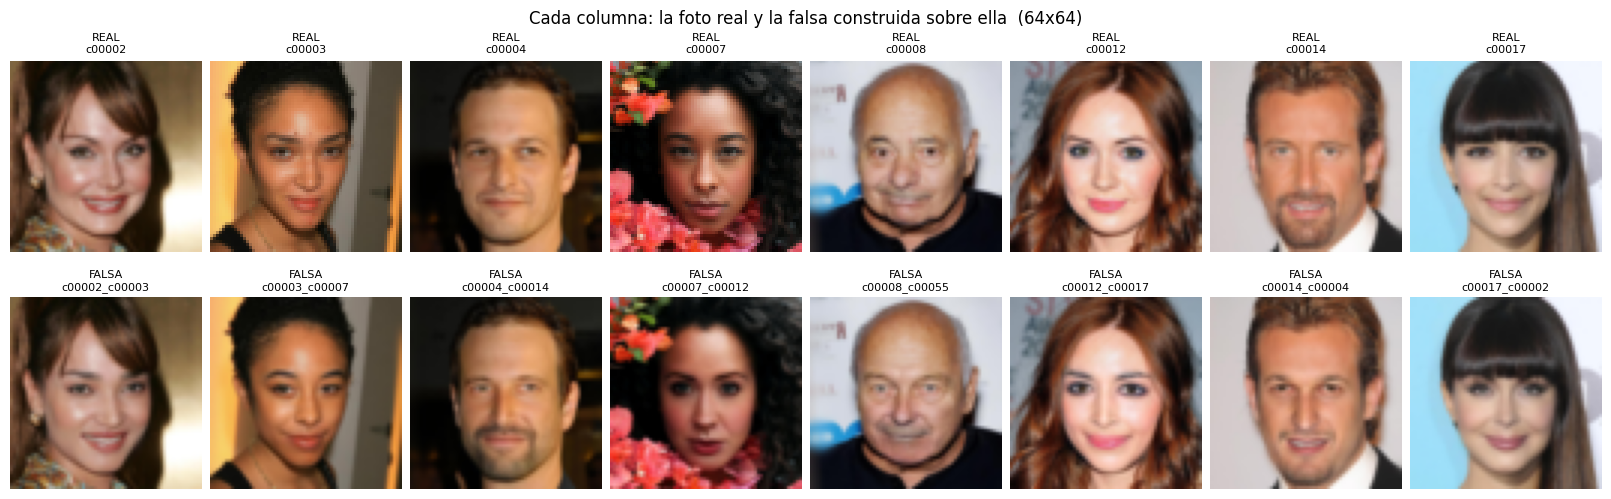

Original:      1024 x 1024 x 3 = 3,145,728 numeros por imagen
Estandarizada:   64 x   64 x 3 = 12,288 numeros por imagen
Reduccion: 256 veces
Las 69,786 imagenes juntas ocupan 858 MB


In [11]:
# Buscamos parejas explicitas: una foto real y la falsa que se construyo sobre ella.
base_de_falsa = np.array([i.split("_")[0] for i in ids[:n_fake]])   # "c00002_c00003" -> "c00002"
pos_real = {v: k for k, v in enumerate(ids[n_fake:])}               # ID real -> su posicion

parejas = []
for j in range(n_fake):
    p = pos_real.get(base_de_falsa[j])
    if p is not None:
        parejas.append((n_fake + p, j))      # (indice de la real, indice de la falsa)
    if len(parejas) == 8:
        break

# constrained_layout evita que los titulos de abajo se monten sobre las imagenes de arriba.
fig, ax = plt.subplots(2, 8, figsize=(16, 5), constrained_layout=True)
for col, (i_real, i_falsa) in enumerate(parejas):
    ax[0, col].imshow(X[i_real]);  ax[0, col].set_title(f"REAL\n{ids[i_real]}",  fontsize=8)
    ax[1, col].imshow(X[i_falsa]); ax[1, col].set_title(f"FALSA\n{ids[i_falsa]}", fontsize=8)
for a in ax.ravel():
    a.axis("off")
fig.suptitle(f"Cada columna: la foto real y la falsa construida sobre ella  ({S}x{S})")
plt.show()

print(f"Original:      1024 x 1024 x 3 = {1024*1024*3:,} numeros por imagen")
print(f"Estandarizada:   {S} x   {S} x 3 = {S*S*3:,} numeros por imagen")
print(f"Reduccion: {1024*1024*3 // (S*S*3)} veces")
print(f"Las {len(X):,} imagenes juntas ocupan {X.nbytes/1e6:.0f} MB")

**En cada columna.** Mismo fondo, mismo pelo, misma ropa, misma pose, misma iluminación.
**Lo único que cambia es la cara.** Eso es exactamente lo que hace un *face swap*, y explica dos
cosas que van a aparecer más adelante:

1. **Por qué el brillo y el color no van a separar las clases.** Las dos imágenes son casi
   idénticas salvo en una región pequeña del centro, así que cualquier medida global de la foto
   sale igual para las dos.
2. **Que la misma persona está a los dos lados de la etiqueta.** La real `c00002` y la falsa
   `c00002_c00003` son la misma fotografía de base.

## 5. Tabla numérica sacada de las imágenes

El `metadata.csv` es todo texto, así que para la parte de `describe` y las gráficas nos faltan
columnas numéricas. Las construimos **midiendo las imágenes**: cuánto pesa el archivo, qué tan
clara es, qué tanto contraste tiene y cuánto rojo, verde y azul tiene en promedio.

In [23]:
# Las medidas se calculan por tandas. Si hicieramos X.std(axis=(1,2,3)) de una sola vez,
# numpy crearia un arreglo intermedio de casi 7 GB y esto no es viable.
brillo, contraste, canales = [], [], []

for i in range(0, len(X), 5000):
    b = X[i:i + 5000].astype(np.float32)
    brillo.append(b.mean(axis=(1, 2, 3)))      # que tan clara es la imagen
    contraste.append(b.std(axis=(1, 2, 3)))    # cuanto varian los pixeles dentro de la imagen
    canales.append(b.mean(axis=(1, 2)))        # promedio de R, G y B por separado

brillo    = np.concatenate(brillo)
contraste = np.concatenate(contraste)
canales   = np.concatenate(canales)            # forma (N, 3)

df = pd.DataFrame({
    "id":        ids,
    "clase":     np.where(y == 1, "falsa", "real"),
    "peso_kb":   peso / 1024,                  # peso del archivo original, en KB
    "brillo":    brillo,
    "contraste": contraste,
    "R":         canales[:, 0],
    "G":         canales[:, 1],
    "B":         canales[:, 2],
})

print(df.shape)
df.head()

(69786, 8)


,id,clase,peso_kb,brillo,contraste,R,G,B
0,c00002_c00003,falsa,282.682617,101.355385,68.193359,125.718262,98.819580,79.528320
1,c00003_c00007,falsa,211.791016,96.201820,60.672794,131.825684,94.648926,62.130859
2,c00004_c00014,falsa,210.156250,67.389404,64.368668,92.743408,65.061523,44.363281
3,c00007_c00012,falsa,312.555664,66.831703,65.106667,98.697266,54.402588,47.395264
4,c00008_c00055,falsa,256.717773,134.234131,74.348351,147.070312,129.873291,125.758789


In [13]:
df.describe()

,peso_kb,brillo,contraste,R,G,B
count,69786.000000,69786.000000,69786.000000,69786.000000,69786.000000,69786.000000
mean,566.515873,112.666817,62.123104,133.657120,108.522888,95.820442
std,511.820654,29.136349,10.550301,31.446730,29.704279,30.169538
min,41.269531,19.502523,23.935158,24.001221,18.478516,9.884033
25%,121.943848,91.697529,54.754059,111.192932,86.927246,73.844421
50%,340.401367,111.760822,61.870771,132.749146,107.615723,94.124634
75%,1147.081299,132.440414,69.030811,155.639038,128.694702,116.291321
max,2089.318359,227.644455,103.398140,242.316162,223.426270,220.360596


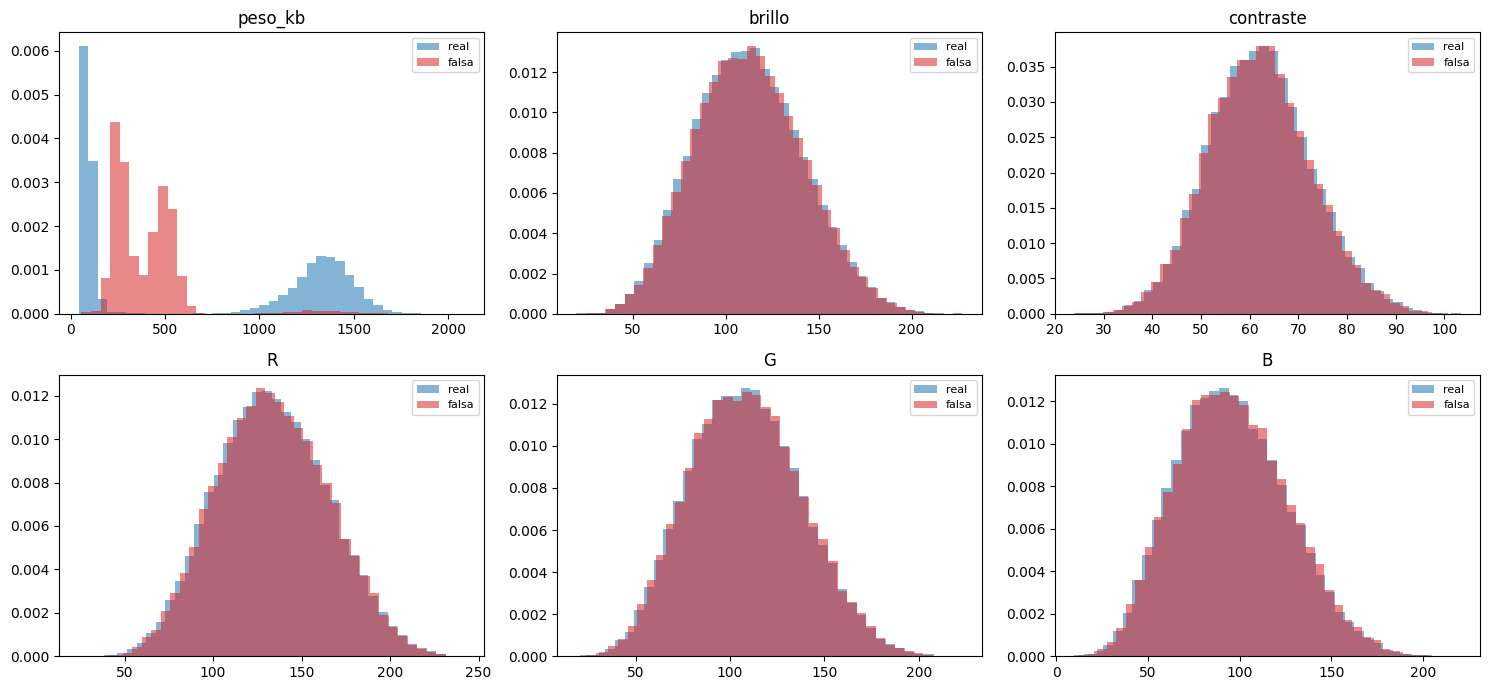

In [14]:
num = ["peso_kb", "brillo", "contraste", "R", "G", "B"]

# Histogramas: como se reparten los valores, separando las dos clases.
# density=True normaliza el area de cada curva, asi comparamos FORMAS y no cantidades:
# sin eso la curva azul se ve mas alta solo porque hay mas imagenes reales que falsas.
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, c in zip(ax.ravel(), num):
    for cl, col in [("real", "tab:blue"), ("falsa", "tab:red")]:
        a.hist(df.loc[df.clase == cl, c], bins=40, alpha=.55, label=cl, color=col, density=True)
    a.set_title(c); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Qué vemos.** Cinco de las seis medidas: brillo, contraste y los promedios de rojo, verde y
azul dan distribuciones **superpuestas**. Ninguna medida global de color distingue
una foto auténtica de una manipulada, tal como anticipaba la grilla de la sección 4.

**La excepción es `peso_kb`.** Las reales forman **dos grupos
separados**: un pico por debajo de 150 KB y otra montaña entre 900 y 1.700 KB. Las falsas están
todas apretadas entre 150 y 650 KB. Por encima de 700 KB **no hay muchas fotos falsas**.

Eso no es una propiedad de los deepfakes: es el rastro de **cómo se guardó cada carpeta** (las
reales mezclan JPG y PNG, las falsas son casi todas JPG a calidad alta). Lo medimos en la
sección 10.

## 6. La imagen promedio

Una imagen es una matriz de números. Si apilamos N imágenes tenemos una caja de
`(N, 64, 64, 3)`. Al hacer `np.mean(X, axis=0)` promediamos **a lo largo del eje de las
imágenes**, no dentro de cada imagen. El resultado es **una sola imagen de 64 × 64** donde el
píxel de la esquina superior izquierda es el promedio de todas las esquinas superiores
izquierdas, y así con cada posición.

El resultado se ve como una cara borrosa. Se ve como una cara **porque el dataset trae los
rostros alineados**: los ojos caen siempre más o menos en la misma coordenada. Si las caras
estuvieran descentradas, el promedio sería una mancha gris sin forma.

Promedio por canal (R, G, B):
  todo   : [133.66 108.52  95.82]
  falsas : [133.88 108.74  96.25]
  reales : [133.48 108.35  95.47]


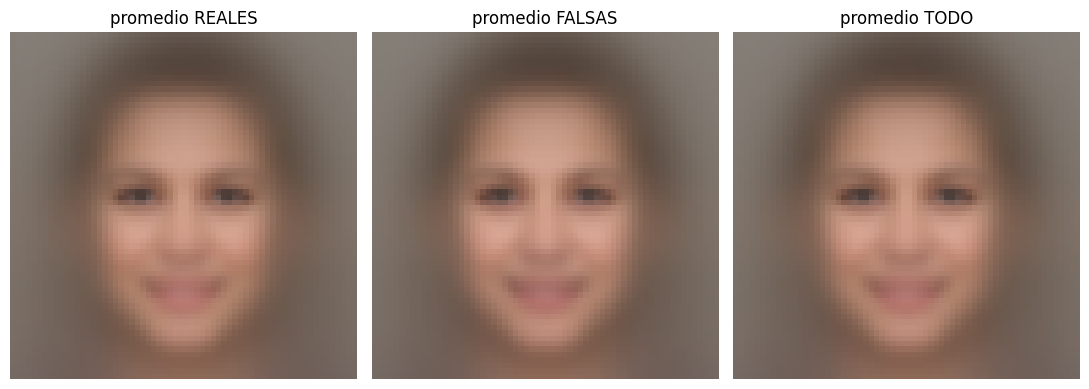

In [15]:
def media_y_desv(A, paso=4000):
    """Promedio y desviacion pixel por pixel, calculados por tandas para no llenar la RAM.
    Usa la identidad:  desviacion = raiz( promedio(x^2) - promedio(x)^2 ),
    asi solo hay que ir acumulando dos sumas y nunca se guarda todo en decimales."""
    n  = len(A)
    s  = np.zeros(A.shape[1:], np.float64)     # suma de los valores
    s2 = np.zeros(A.shape[1:], np.float64)     # suma de los valores al cuadrado
    for i in range(0, n, paso):
        b = A[i:i + paso].astype(np.float64)
        s  += b.sum(axis=0)
        s2 += (b ** 2).sum(axis=0)
    m = s / n
    return m, np.sqrt(np.maximum(s2 / n - m ** 2, 0))


# X[:n_fake] y X[n_fake:] son vistas: no copian memoria.
media_fake, std_fake = media_y_desv(X[:n_fake])
media_real, std_real = media_y_desv(X[n_fake:])
media_todo, std_todo = media_y_desv(X)

print("Promedio por canal (R, G, B):")
print("  todo   :", media_todo.mean(axis=(0, 1)).round(2))
print("  falsas :", media_fake.mean(axis=(0, 1)).round(2))
print("  reales :", media_real.mean(axis=(0, 1)).round(2))

fig, ax = plt.subplots(1, 3, figsize=(11, 4))
for a, (im, t) in zip(ax, [(media_real, "promedio REALES"),
                           (media_fake, "promedio FALSAS"),
                           (media_todo, "promedio TODO")]):
    a.imshow(im.astype(np.uint8)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

**Lo que sale.** Las tres caras promedio son prácticamente iguales y los promedios por canal
casi coinciden. Es decir: **mirando el promedio no se distinguen las clases.**

No es un fracaso, es exactamente lo que anuncia el dataset: fue construido para que no se note
la diferencia. Nos dice que la señal no está en el color ni en la forma general, sino en detalles
finos, que es lo que vamos a medir en el siguiente avance.

## 7. La imagen de desviación estándar

Misma operación pero con `np.std`: en vez de "cuánto vale en promedio este píxel", responde
**"cuánto cambia este píxel de una imagen a otra"**.

- **Zonas oscuras** (desviación baja): píxeles casi iguales en todas las imágenes. Es el centro
  del rostro, que está alineado.
- **Zonas claras** (desviación alta): píxeles que cambian mucho. Es el fondo, el pelo, los hombros.

Y de paso comparamos las dos caras promedio restándolas, para ver si hay alguna zona donde sí
se diferencien.

Desviacion promedio ->  reales: 62.28   falsas: 61.76


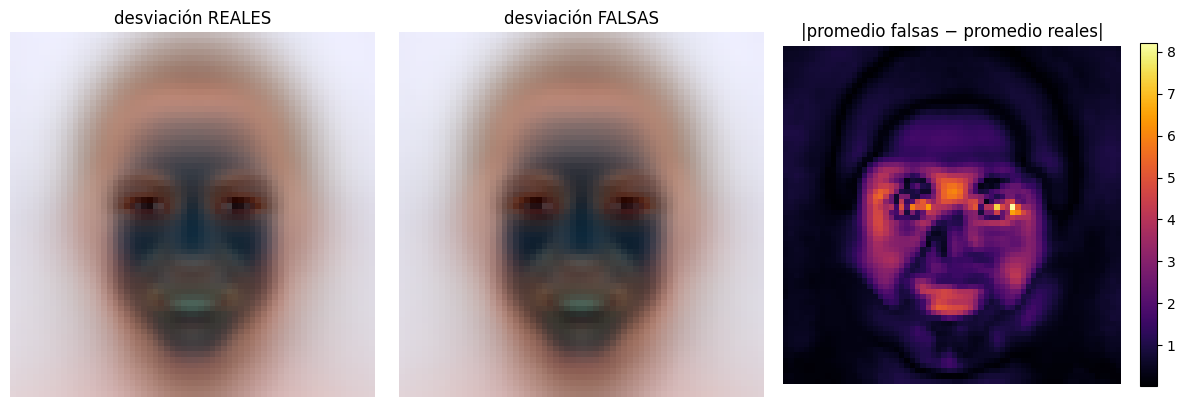

Diferencia entre las caras promedio ->  maxima: 11.38   promedio: 1.02   (escala 0-255)


In [22]:
print("Desviacion promedio ->  reales: %.2f   falsas: %.2f" % (std_real.mean(), std_fake.mean()))

def norm(a):
    """Lleva los valores al rango 0-1 para poder dibujarlos."""
    a = a - a.min()
    return a / max(a.max(), 1e-6)

dif = np.abs(media_fake - media_real)     # diferencia entre las dos caras promedio

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(norm(std_real)); ax[0].set_title("desviación REALES")
ax[1].imshow(norm(std_fake)); ax[1].set_title("desviación FALSAS")
h = ax[2].imshow(dif.mean(axis=2), cmap="inferno")
ax[2].set_title("|promedio falsas − promedio reales|")
plt.colorbar(h, ax=ax[2], fraction=.046)
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

print("Diferencia entre las caras promedio ->  maxima: %.2f   promedio: %.2f   (escala 0-255)"
      % (dif.max(), dif.mean()))

### 7.1 ¿Esa diferencia es real o es azar?

La diferencia promedio entre las dos caras es de **1,02 sobre 255**. Antes de decir que
encontramos algo hay que descartar que sea simple ruido de muestreo: aunque las dos clases fueran
idénticas, sus promedios nunca darían exactamente lo mismo.

El error estándar de un promedio es `desviación / √n`. Con ese valor se calcula cuánta diferencia
esperaríamos **solo por azar** y se compara con la que medimos.

In [17]:
# ¿La diferencia entre las caras promedio es señal real o ruido de muestreo?
# El error estandar de un promedio es  desviacion / raiz(n).
ee_real = std_real.mean() / np.sqrt(len(X) - n_fake)
ee_fake = std_fake.mean() / np.sqrt(n_fake)
# Diferencia entre dos promedios esperada por puro azar:
ruido = np.sqrt(ee_real**2 + ee_fake**2) * np.sqrt(2/np.pi)

print("Diferencia promedio observada : %.2f" % dif.mean())
print("Esperada solo por azar        : %.2f" % ruido)
print("Diferencia maxima observada   : %.2f" % dif.max())
print("-> la observada es %.1f veces el ruido de muestreo" % (dif.mean()/ruido))

Diferencia promedio observada : 1.02
Esperada solo por azar        : 0.38
Diferencia maxima observada   : 11.38
-> la observada es 2.7 veces el ruido de muestreo


**Resultado: la diferencia es real y es pequeña.** Esperaríamos 0,38 por puro azar y medimos
1,02, o sea **2,7 veces el ruido**; y el máximo de 11,38 está unas 30 veces por encima.

Este cálculo justifica de paso una decisión del proyecto. En una prueba anterior con **320
imágenes por clase** la diferencia daba 5,23 y el ruido esperado era ~4,9: con ese tamaño de
muestra lo que se estaba midiendo era **básicamente ruido**. Con las 69.786 imágenes el ruido se
promedia y queda la señal. Ese es el motivo de haber descargado el dataset completo en vez de
trabajar con una muestra.

## 8. Escala de grises

El profesor recomendó trabajar en escala de grises y calcular el promedio y la desviación con
`np.mean` y `np.std`. Aquí está, sobre las 69.786 imágenes.

**Una precision sobre la recomendación:**

1. `mpimg.imread` devuelve **decimales entre 0 y 1 si el archivo es PNG** y **enteros de 0 a 255
   si es JPG**. Nuestro dataset mezcla los dos formatos (casi la mitad de las reales son PNG), así
   que leerlo con `mpimg` sin cuidado daría promedios en escalas distintas. Por eso decodificamos
   todo con PIL y forzamos `uint8` desde el principio.

**No convertimos el dataset a grises**, solo agregamos esta vista: las estadísticas de color son
una de las características que vamos a usar en el siguiente avance, y pasar a grises las borraría.

color: (69786, 64, 64, 3)  ->  gris: (69786, 64, 64)
memoria: 858 MB en color  ->  286 MB en gris

np.mean(todos) = 112.3412
np.std(todos)  = 65.0352

          promedio   desviacion
falsas   112.6324    64.9903
reales   112.1050    65.0707

canal rojo (img[:,:,0]) -> promedio 133.6571   desviacion 72.3931


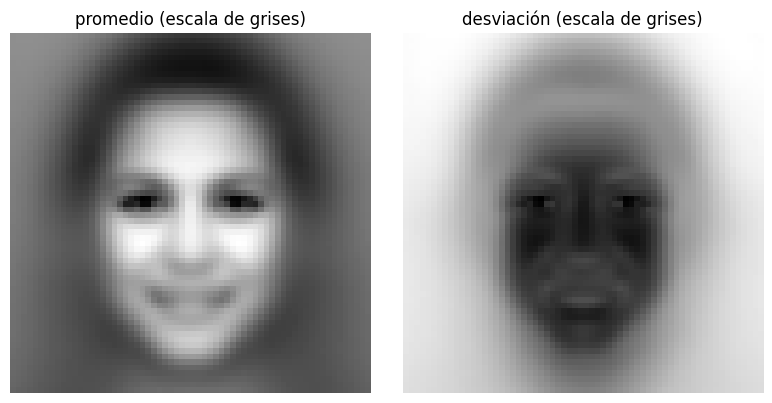

In [18]:
# Pasamos a escala de grises. Lo hacemos por tandas: el promedio sobre el eje del color
# genera decimales y de una sola vez ocuparia 2,3 GB.
X_gris = np.empty(X.shape[:3], np.uint8)
for i in range(0, len(X), 5000):
    X_gris[i:i+5000] = X[i:i+5000].mean(axis=3).astype(np.uint8)

X_rojo = X[..., 0]          # el canal rojo, que es lo que devuelve img[:,:,0]

print("color:", X.shape, " ->  gris:", X_gris.shape)
print(f"memoria: {X.nbytes/1e6:.0f} MB en color  ->  {X_gris.nbytes/1e6:.0f} MB en gris\n")

# PROMEDIO Y DESVIACION DE LAS IMAGENES (un solo numero, como en la recomendacion)
print("np.mean(todos) = %.4f" % X_gris.mean())
print("np.std(todos)  = %.4f" % X_gris.std())

print("\n          promedio   desviacion")
print("falsas   %8.4f   %8.4f" % (X_gris[:n_fake].mean(), X_gris[:n_fake].std()))
print("reales   %8.4f   %8.4f" % (X_gris[n_fake:].mean(), X_gris[n_fake:].std()))
print("\ncanal rojo (img[:,:,0]) -> promedio %.4f   desviacion %.4f"
      % (X_rojo.mean(), X_rojo.std()))

# Las mismas dos imagenes de antes, ahora en escala de grises.
media_gris, std_gris = media_y_desv(X_gris)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(media_gris, cmap="gray"); ax[0].set_title("promedio (escala de grises)")
ax[1].imshow(std_gris,   cmap="gray"); ax[1].set_title("desviación (escala de grises)")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

**Lo que confirma.** En escala de grises el promedio general es 112,34 y la desviación 65,04.
Separado por clase: **112,63 en las falsas contra 112,11 en las reales**, medio punto sobre 255.
Pasar a grises no cambia la conclusión de las secciones 6 y 7 — las dos clases siguen siendo
indistinguibles con estadísticas globales.

## 9. Para qué sirven el promedio y la desviación

No son solo un dibujo bonito. Son el paso de **normalización** que casi todos los algoritmos
necesitan antes de entrenar:

`z = (x − promedio) / desviación`

Eso deja cada píxel con promedio 0 y desviación 1, de modo que ninguna zona de la imagen pese
más que otra solo porque sus números son más grandes.

In [19]:
# Lo aplicamos sobre una tanda de 4.000 imagenes y no sobre las 69.786,
# porque en decimales el conjunto completo ocuparia 3,4 GB solo para esta demostracion.
tanda   = X[:4000].astype(np.float32)
tanda_z = (tanda - media_todo) / (std_todo + 1e-6)   # el +1e-6 evita dividir entre cero

print("antes   ->  promedio %6.2f   desviacion %6.2f" % (tanda.mean(),   tanda.std()))
print("despues ->  promedio %6.2f   desviacion %6.2f" % (tanda_z.mean(), tanda_z.std()))

antes   ->  promedio 113.85   desviacion  68.47
despues ->  promedio   0.02   desviacion   0.99


## 10. Dos trampas que encontramos en los datos

Al explorar aparecieron dos atajos por los que un modelo podría acertar muchísimo **sin haber
aprendido nada sobre deepfakes**. Hay que medirlos y cerrarlos antes de comenzar a realizar fases posteriores.

In [20]:
# --- Trampa 1: el peso del archivo depende de como se guardo cada carpeta ---
print("Peso mediano del archivo original, por clase (KB):")
print(df.groupby("clase")["peso_kb"].median().round(1), "\n")

# Regla de UN umbral: "si pesa mas de X, es falsa".
aciertos = []
for t in np.percentile(df["peso_kb"], np.arange(1, 100)):
    pred = (df["peso_kb"].values > t).astype(int)
    aciertos.append(max((pred == y).mean(), (pred != y).mean()))   # probamos los dos sentidos
print("Regla de un umbral  ('si pesa mas de X es falsa')     : %.1f%%" % (100 * max(aciertos)))

# Regla de DOS umbrales: las falsas viven en una franja y las reales a los dos lados.
mejor = max(((df["peso_kb"].between(a, b)).astype(int) == y).mean()
            for a in np.percentile(df["peso_kb"], np.arange(1, 60))
            for b in np.percentile(df["peso_kb"], np.arange(40, 100)) if b > a)
print("Regla de dos umbrales ('si pesa entre A y B es falsa') : %.1f%%" % (100 * mejor))
print("Acertar siempre 'real' ya daria                        : %.1f%%"
      % (100 * (len(X) - n_fake) / len(X)))

# --- Trampa 2: la misma persona aparece en las dos clases ---
comunes = set(base_de_falsa) & set(ids[n_fake:])
print("\nPersonas que aparecen como real Y como base de una falsa: %d de %d falsas (%.1f%%)"
      % (len(comunes), n_fake, 100 * len(comunes) / n_fake))

Peso mediano del archivo original, por clase (KB):
clase
falsa    349.5
real     182.3
Name: peso_kb, dtype: float64 

Regla de un umbral  ('si pesa mas de X es falsa')     : 71.9%
Regla de dos umbrales ('si pesa entre A y B es falsa') : 97.5%
Acertar siempre 'real' ya daria                        : 55.2%

Personas que aparecen como real Y como base de una falsa: 30867 de 31246 falsas (98.8%)


**Qué significan y qué hacemos**

**1. El peso del archivo casi etiqueta solo.** Mediana de 349,5 KB en las falsas contra 182,3 KB
en las reales, pero el problema no es la mediana sino la forma de la distribución: las reales
mezclan JPG livianos (menos de 150 KB) y PNG de más de 1 MB, mientras que las falsas están todas
en una franja estrecha entre 150 y 650 KB.

Por eso una regla de un solo umbral acierta el 71,9 %, pero una de **dos** umbrales —"si pesa
entre A y B es falsa"— llega al **97,5 %**, contra un 55,2 % de simplemente responder "real"
siempre. Una regla que no mira la cara para nada clasifica casi perfecto: eso no detecta
deepfakes, detecta con qué programa se guardó el archivo.

*Qué hacemos:* no usar nunca el peso ni el formato como característica, y al preparar las
imágenes volver a guardarlas todas con la **misma calidad**, para borrar esa pista. Reducir a
64 × 64 ya elimina buena parte de ella, porque al encoger 256 veces se pierde el rastro fino que
deja el compresor.

**2. La misma persona está en las dos clases.** El **98,8 %** de las falsas (30.867 de 31.246)
tiene su fotografía base entre las reales — es lo que se ve en la grilla de la sección 4. Si al
evaluar el modelo la real queda en entrenamiento y su falsa en prueba, el modelo puede estar
reconociendo la cara en vez de detectar la manipulación.

*Qué hacemos:* queda anotado para el Avance 2, donde al evaluar hay que **agrupar por persona**
en vez de repartir las imágenes al azar.

Encontrar estas dos cosas ahora es la parte más útil de esta exploración: son dos formas de
obtener un resultado excelente y falso.

## 11. Guardar el resultado

Guardamos las imágenes ya procesadas en Drive. Los avances siguientes arrancan cargando este
archivo y se saltan por completo la descarga.

In [21]:
# Guardamos el resultado final en Drive. Los avances siguientes empiezan cargando esto
# y se saltan toda la descarga.
np.save(f"{CARPETA}/X_{S}.npy",  X)
np.save(f"{CARPETA}/y.npy",      y)
np.save(f"{CARPETA}/ids.npy",    ids)
np.save(f"{CARPETA}/peso.npy",   peso)
df.to_csv(f"{CARPETA}/tabla.csv", index=False)

print("Guardado en", CARPETA)
for f in sorted(glob.glob(f"{CARPETA}/*.npy")) + [f"{CARPETA}/tabla.csv"]:
    print(f"  {os.path.basename(f):15s} {os.path.getsize(f)/1e6:8.1f} MB")

# Para cargarlo en el siguiente avance:
# X = np.load(f"{CARPETA}/X_64.npy"); y = np.load(f"{CARPETA}/y.npy")

Guardado en /content/drive/MyDrive/IA1_deepfake
  X_64.npy           857.5 MB
  ids.npy              5.6 MB
  peso.npy             0.6 MB
  y.npy                0.1 MB
  tabla.csv            5.4 MB


## 12. Conclusiones de este avance

1. **La tarea es clasificación binaria:** real o falsa.
2. **Los datos están listos:** las **69.786 imágenes** del dataset completo (31.246 falsas y
   38.540 reales), reducidas a 64 × 64 y guardadas en Drive en 857 MB, más la tabla de medidas y
   el CSV demográfico.
3. **Estandarizamos a 64 × 64**, 256 veces menos datos por imagen, conservando un rostro legible.
4. **Ninguna medida global separa las clases.** Brillo, contraste y color se superponen,
   y la cara promedio de las falsas es indistinguible de la de las reales: la
   diferencia es de 1,02 sobre 255, apenas 2,7 veces el ruido de muestreo. Era el resultado
   esperado, porque el dataset está construido para ser indistinguible a simple vista.
5. **Pero la diferencia no está repartida al azar:** el mapa `|promedio falsas − promedio reales|`
   se ilumina **solo en la región del rostro** —ojos, nariz, boca— y queda negro en el fondo y el
   pelo. Ahí es donde hay que buscar la señal.
6. **Detectamos dos trampas.** El peso del archivo permite acertar el **97,5 %** sin mirar la
   imagen, y el **98,8 %** de las falsas comparte su fotografía base con una real. Las dos
   producirían un resultado excelente y falso, y ya sabemos cómo evitar estos atajos.